# Logistic Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv('../data/cleaned_data.csv')

In [3]:
X = df.drop(columns=['target'])
y = df['target']
print('Columns:', X.columns.tolist())

Columns: ['Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'career_ft_pct', 'prev_ft_pct', 'career_seasons', 'height_in', 'weight_lb', 'ast_to_tov', 'pts_per_fga', 'threep_rate', 'reb_per_min', 'stocks_per_min', 'scoring_load', 'Pos_C', 'Pos_PF', 'Pos_PG', 'Pos_SF', 'Pos_SG']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, '  Test:', X_test.shape)

Train: (12016, 39)   Test: (3004, 39)


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [6]:
lr = LogisticRegression(max_iter=1000, solver='liblinear')  # liblinear solver

In [7]:
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [8]:
y_pred = lr.predict(X_test_scaled)

In [9]:
acc = accuracy_score(y_test, y_pred)
print(f'Logistic Regression Test Accuracy: {acc * 100:.2f}%')
print(classification_report(y_test, y_pred, target_names=['Below-Average', 'Good']))

Logistic Regression Test Accuracy: 74.23%
               precision    recall  f1-score   support

Below-Average       0.73      0.70      0.71      1383
         Good       0.75      0.78      0.77      1621

     accuracy                           0.74      3004
    macro avg       0.74      0.74      0.74      3004
 weighted avg       0.74      0.74      0.74      3004



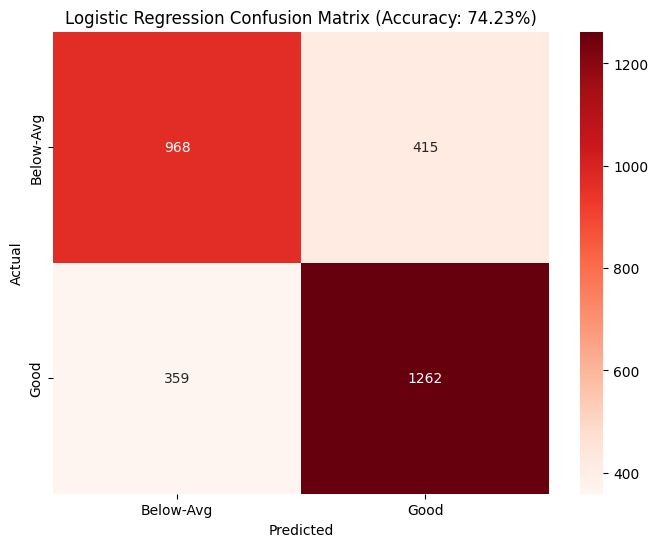

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Below-Avg', 'Good'],
            yticklabels=['Below-Avg', 'Good'])
plt.title(f'Logistic Regression Confusion Matrix (Accuracy: {acc*100:.2f}%)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../images/lr_confusion_matrix.png', bbox_inches='tight')
plt.show()

In [11]:
joblib.dump(lr, '../models/logistic.pkl')
joblib.dump(scaler, '../models/logistic_scaler.pkl')

['../models/logistic_scaler.pkl']